## **Vector Databases**

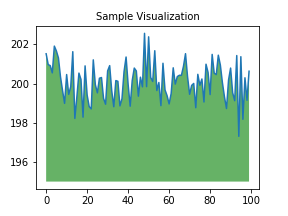

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentences = [
    # Cricket sentences (4 sentences)
    "The batsman hit a magnificent six over the boundary",
    "The spinner deceived the batsman with a perfect googly",
    "Rain interrupted play during the third session of the test match",
    "The captain won the toss and decided to bat first",

    # Cooking sentences (3 sentences)
    "Marinate the chicken with spices for at least two hours",
    "Preheat the oven to 350 degrees before baking the cake",
    "Chop the vegetables finely and sauté them in olive oil",

    # Cybersecurity sentences (3 sentences)
    "Enable two-factor authentication to protect your online accounts",
    "Hackers exploited a vulnerability in the outdated software system",
    "Regular security patches are essential to prevent data breaches"
]

In [ ]:
print("=" * 70)
print("SENTENCES BY TOPIC")
print("=" * 70)
print("CRICKET:")
for i in range(4):
    print(f"{i+1}. {sentences[i]}")

print("COOKING:")
for i in range(4, 7):
    print(f"{i+1}. {sentences[i]}")

print("CYBERSECURITY:")
for i in range(7, 10):
    print(f"{i+1}. {sentences[i]}")

SENTENCES BY TOPIC
CRICKET:
1. The batsman hit a magnificent six over the boundary
2. The spinner deceived the batsman with a perfect googly
3. Rain interrupted play during the third session of the test match
4. The captain won the toss and decided to bat first
COOKING:
5. Marinate the chicken with spices for at least two hours
6. Preheat the oven to 350 degrees before baking the cake
7. Chop the vegetables finely and sauté them in olive oil
CYBERSECURITY:
8. Enable two-factor authentication to protect your online accounts
9. Hackers exploited a vulnerability in the outdated software system
10. Regular security patches are essential to prevent data breaches


In [ ]:
print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Number of sentences: {len(sentences)}")
print(f"Embedding dimensions: {embeddings.shape[1]}")
print(f"Embeddings shape: {embeddings.shape}")

Model loaded: all-MiniLM-L6-v2
Number of sentences: 10
Embedding dimensions: 384
Embeddings shape: (10, 384)


In [ ]:
print("" + "=" * 70)
print("COSINE SIMILARITY MATRIX")
print("=" * 70)

similarity_matrix = cosine_similarity(embeddings)

COSINE SIMILARITY MATRIX


In [ ]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i+1}" for i in range(10)],
    columns=[f"S{i+1}" for i in range(10)]
)

print("Similarity Matrix (rounded to 3 decimal places):")
print(similarity_df.round(3))

Similarity Matrix (rounded to 3 decimal places):
        S1     S2     S3     S4     S5     S6     S7     S8     S9    S10
S1   1.000  0.441  0.182  0.436 -0.010 -0.005  0.056  0.049  0.034  0.049
S2   0.441  1.000  0.204  0.449  0.012  0.009  0.084  0.015  0.072  0.039
S3   0.182  0.204  1.000  0.292 -0.040  0.002 -0.013 -0.062 -0.004  0.005
S4   0.436  0.449  0.292  1.000  0.024  0.080  0.009  0.000 -0.022 -0.068
S5  -0.010  0.012 -0.040  0.024  1.000  0.085  0.300 -0.034 -0.002 -0.024
S6  -0.005  0.009  0.002  0.080  0.085  1.000  0.190  0.044 -0.063 -0.039
S7   0.056  0.084 -0.013  0.009  0.300  0.190  1.000  0.019  0.011 -0.007
S8   0.049  0.015 -0.062  0.000 -0.034  0.044  0.019  1.000  0.063  0.217
S9   0.034  0.072 -0.004 -0.022 -0.002 -0.063  0.011  0.063  1.000  0.492
S10  0.049  0.039  0.005 -0.068 -0.024 -0.039 -0.007  0.217  0.492  1.000


SIMILARITY HEATMAP


<Axes: >

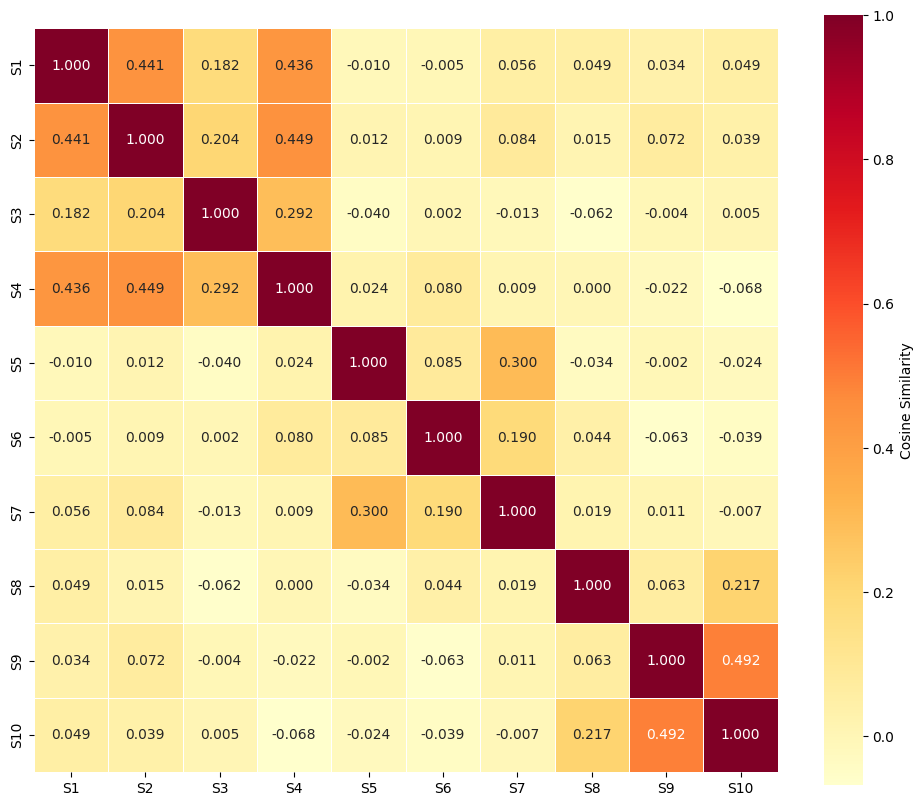

In [ ]:
print("" + "=" * 70)
print("SIMILARITY HEATMAP")
print("=" * 70)

plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    xticklabels=[f"S{i+1}" for i in range(10)],
    yticklabels=[f"S{i+1}" for i in range(10)],
    cbar_kws={'label': 'Cosine Similarity'},
    square=True,
    linewidths=0.5
)



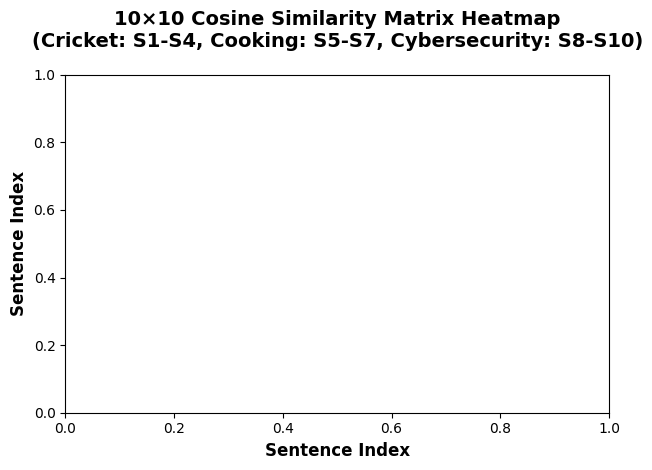

Heatmap displayed above!


In [ ]:
plt.title('10×10 Cosine Similarity Matrix Heatmap\n(Cricket: S1-S4, Cooking: S5-S7, Cybersecurity: S8-S10)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Sentence Index', fontsize=12, fontweight='bold')
plt.ylabel('Sentence Index', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Heatmap displayed above!")


# New Section

In [ ]:
print("" + "=" * 70)
print("QUERY SENTENCE SIMILARITY SEARCH")
print("=" * 70)

query_sentence = "The bowler took three wickets in one over"
print(f"Query: '{query_sentence}'")

# Generate embedding for the query
query_embedding = model.encode([query_sentence])

# Compute similarity between query and all sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Create a list of (sentence, similarity) pairs
sentence_similarity_pairs = list(zip(sentences, query_similarities, range(1, 11)))

# Sort by similarity in descending order
sorted_pairs = sorted(sentence_similarity_pairs, key=lambda x: x[1], reverse=True)

# Display top 2 most similar sentences
print("" + "-" * 70)
print("TOP 2 MOST SIMILAR SENTENCES:")
print("-" * 70)

for rank, (sentence, similarity, original_index) in enumerate(sorted_pairs[:2], 1):
    print(f"Rank {rank}:")
    print(f"  Sentence {original_index}: {sentence}")
    print(f"  Similarity Score: {similarity:.4f}")


QUERY SENTENCE SIMILARITY SEARCH
Query: 'The bowler took three wickets in one over'
----------------------------------------------------------------------
TOP 2 MOST SIMILAR SENTENCES:
----------------------------------------------------------------------
Rank 1:
  Sentence 1: The batsman hit a magnificent six over the boundary
  Similarity Score: 0.5523
Rank 2:
  Sentence 4: The captain won the toss and decided to bat first
  Similarity Score: 0.5202


In [ ]:
print("" + "-" * 70)
print("ALL SIMILARITY SCORES (sorted by relevance):")
print("-" * 70)

for rank, (sentence, similarity, original_index) in enumerate(sorted_pairs, 1):
    print(f"{rank}. [S{original_index}] {similarity:.4f} - {sentence}")

# Summary statistics
print("" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"Highest similarity: {query_similarities.max():.4f}")
print(f"Lowest similarity: {query_similarities.min():.4f}")
print(f"Average similarity: {query_similarities.mean():.4f}")
print(f"Standard deviation: {query_similarities.std():.4f}")

print("" + "=" * 70)
print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("=" * 70)

----------------------------------------------------------------------
ALL SIMILARITY SCORES (sorted by relevance):
----------------------------------------------------------------------
1. [S1] 0.5523 - The batsman hit a magnificent six over the boundary
2. [S4] 0.5202 - The captain won the toss and decided to bat first
3. [S2] 0.4625 - The spinner deceived the batsman with a perfect googly
4. [S3] 0.2386 - Rain interrupted play during the third session of the test match
5. [S9] 0.0888 - Hackers exploited a vulnerability in the outdated software system
6. [S7] 0.0877 - Chop the vegetables finely and sauté them in olive oil
7. [S6] 0.0350 - Preheat the oven to 350 degrees before baking the cake
8. [S5] 0.0257 - Marinate the chicken with spices for at least two hours
9. [S10] -0.0210 - Regular security patches are essential to prevent data breaches
10. [S8] -0.0421 - Enable two-factor authentication to protect your online accounts
SUMMARY STATISTICS
Highest similarity: 0.5523
Lowest sim